In [8]:
#Importando as bibliotecas necessárias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
#Criando o dataset
numeros = np.arange(1, 101)

numeros

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [3]:
#Transformando em um dataframe
df = pd.DataFrame({
    "numero": numeros
})

df.head()

,numero
0,1
1,2
2,3
3,4
4,5


In [5]:
#Criação das features matemáticas
df["quadrado"] = df["numero"] ** 2
df["raiz"] = np.sqrt(df["numero"])
df["log"] = np.log(df["numero"])
df.head(10)

,numero,quadrado,raiz,log
0,1,1,1.000000,0.000000
1,2,4,1.414214,0.693147
2,3,9,1.732051,1.098612
3,4,16,2.000000,1.386294
4,5,25,2.236068,1.609438
5,6,36,2.449490,1.791759
6,7,49,2.645751,1.945910
7,8,64,2.828427,2.079442
8,9,81,3.000000,2.197225
9,10,100,3.162278,2.302585


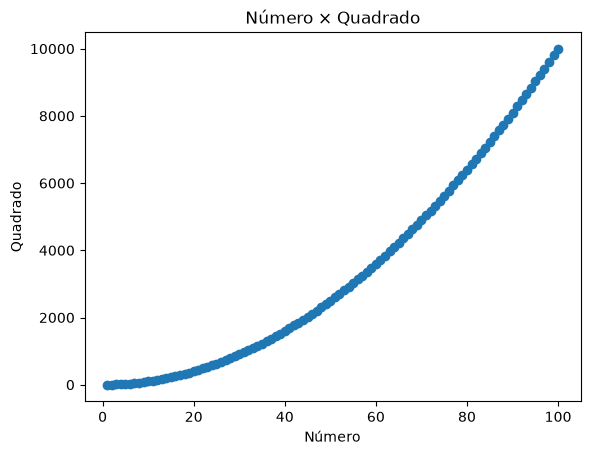

In [6]:
#Visualizando a relação entre número e quadrado
plt.scatter(
    df["numero"],
    df["quadrado"]
)

plt.xlabel("Número")
plt.ylabel("Quadrado")
plt.title("Número × Quadrado")

plt.show()

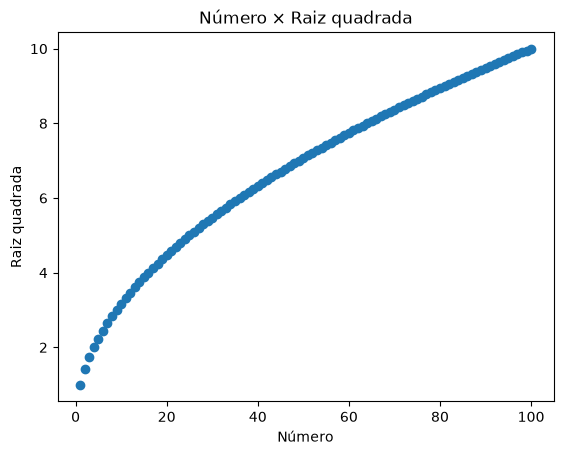

In [7]:
#Visualizando a relação entre número e raiz
plt.scatter(
    df["numero"],
    df["raiz"]
)

plt.xlabel("Número")
plt.ylabel("Raiz quadrada")
plt.title("Número × Raiz quadrada")

plt.show()

In [12]:
#Normalização das features (StandardScaler)
from sklearn.preprocessing import StandardScaler

features = [
    "numero",
    "quadrado",
    "raiz",
    "log"
]

X = df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-1.71481604, -1.12405437, -2.45605979, -3.93912583],
       [-1.68017329, -1.12305742, -2.27803718, -3.18848014],
       [-1.64553055, -1.12139585, -2.14143562, -2.74938055],
       [-1.6108878 , -1.11906965, -2.02627518, -2.43783444],
       [-1.57624505, -1.11607882, -1.9248168 , -2.1961805 ]])

In [18]:
#Aplicando a distância euclidiana no conjunto de dados - Valores aleatórios
def distancia(a, b):
    return np.sqrt(np.sum((a - b) ** 2))


a = np.array([1, 2, 3])
b = np.array([4, 6, 8])

distancia(a, b)

np.float64(7.0710678118654755)

In [23]:
# Construindo o K-Means

def atribuir_clusters(X, centroides):
    clusters = []

    for ponto in X:
        distancias = []

        for centroide in centroides:
            d = distancia(ponto, centroide)
            distancias.append(d)

        cluster = np.argmin(distancias)
        clusters.append(cluster)

    return np.array(clusters)


def atualizar_centroides(X, clusters, k):
    novos_centroides = []

    for i in range(k):
        pontos_cluster = X[clusters == i]

        centroide = np.mean(pontos_cluster, axis=0)

        novos_centroides.append(centroide)

    return np.array(novos_centroides)


def kmeans(X, k):
    centroides = X[:k].copy()

    for _ in range(100):

        clusters = atribuir_clusters(
            X,
            centroides
        )

        novos_centroides = atualizar_centroides(
            X,
            clusters,
            k
        )

        if np.allclose(
            centroides,
            novos_centroides
        ):
            break

        centroides = novos_centroides

    return clusters, centroides

In [25]:
#Visualizando o K-Means
clusters, centroides = kmeans(X_scaled, 3)

print("Clusters:")
print(clusters)

print("\nCentroides:")
print(centroides)
#Conclui-se que o cluster 0 têm valores menores em comparação com o o cluster 1. O cluster 2 obtém os maiores valores.

Clusters:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]

Centroides:
[[-1.35106718 -1.0670624  -1.50000453 -1.55312571]
 [-0.27714199 -0.47986238 -0.1109999   0.07849378]
 [ 1.0739252   1.12289127  0.98526567  0.81655302]]


In [30]:
#Verificando o resultado do K-Means
df["cluster"] = clusters
df.groupby("cluster")["numero"].agg(
    ["min", "max", "mean", "count"]
)

,min,max,mean,count
cluster,,,,
0,1,22,11.5,22
1,23,62,42.5,40
2,63,100,81.5,38


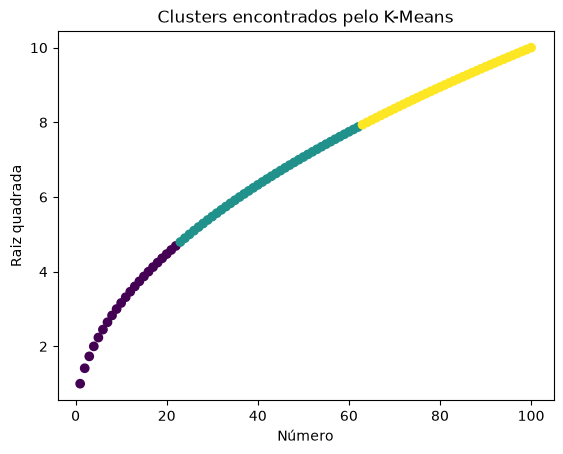

In [31]:
#Visualizando o resultado - Features aleatórios
plt.scatter(
    df["numero"],
    df["raiz"],
    c=df["cluster"]
)

plt.xlabel("Número")
plt.ylabel("Raiz quadrada")
plt.title("Clusters encontrados pelo K-Means")

plt.show()

In [32]:
#Implementando a inertia no K-Means recebido
def calcular_inertia(X, clusters, centroides):

    inertia = 0

    for i, ponto in enumerate(X):

        cluster = clusters[i]

        centroide = centroides[cluster]

        distancia_ponto = distancia(
            ponto,
            centroide
        )

        inertia += distancia_ponto ** 2

    return inertia

inertia = calcular_inertia(
    X_scaled,
    clusters,
    centroides
)

print(inertia)

65.23601414438828


In [34]:
#Testando valores de k (sem scikit-learn)
valores_k = range(1, 11)

inertias = []

for k in valores_k:

    clusters_k, centroides_k = kmeans(
        X_scaled,
        k
    )

    inertia_k = calcular_inertia(
        X_scaled,
        clusters_k,
        centroides_k
    )

    inertias.append(inertia_k)

print(inertias)

[np.float64(400.00000000000006), np.float64(132.42618254038362), np.float64(65.23601414438828), np.float64(38.76663648777456), np.float64(25.35081156731008), np.float64(19.226785875046996), np.float64(16.09222457722096), np.float64(13.920931522385219), np.float64(11.337512712656707), np.float64(9.693913374557301)]


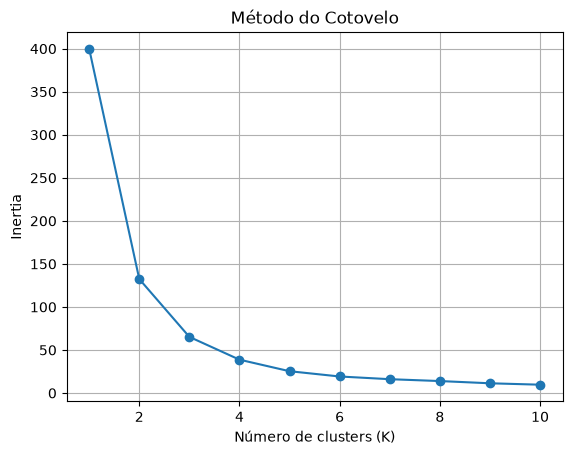

In [35]:
#Visualizando o resultado dos possíveis valores de k testados
plt.plot(
    list(valores_k),
    inertias,
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inertia")
plt.title("Método do Cotovelo")

plt.grid()
plt.show()

In [36]:
#Testando possíveis valores de k (com scikit-learn)
from sklearn.cluster import KMeans

inertias_sklearn = []

for k in range(1, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_scaled)

    inertias_sklearn.append(
        modelo.inertia_
    )

C:\Users\pedro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pedro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pedro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pedro\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Window

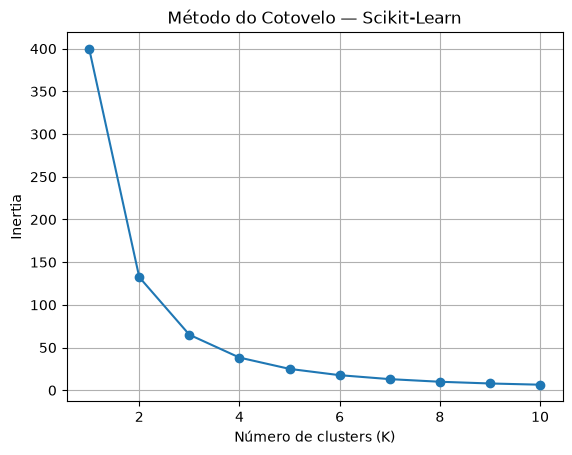

In [37]:
#Visualizando os possíveis valores de k (com scikit-learn)
plt.plot(
    range(1, 11),
    inertias_sklearn,
    marker="o"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inertia")
plt.title("Método do Cotovelo — Scikit-Learn")

plt.grid()
plt.show()

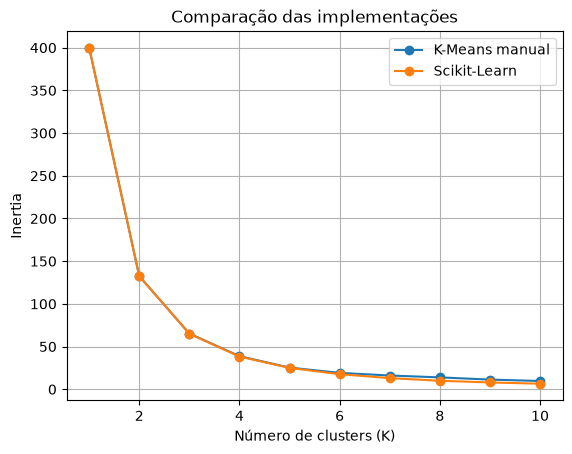

In [38]:
#Comparação das implementações
plt.plot(
    range(1, 11),
    inertias,
    marker="o",
    label="K-Means manual"
)

plt.plot(
    range(1, 11),
    inertias_sklearn,
    marker="o",
    label="Scikit-Learn"
)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Inertia")
plt.title("Comparação das implementações")

plt.legend()
plt.grid()

plt.show()